# Fine-tuning Qwen3-VL con LoRA para Clasificación de Memes

**Pipeline:**
1. Carga de datos desde JSON preprocesados (train/dev/test)
2. Carga de Qwen3-VL en bf16 (sin cuantización)
3. Configuración de LoRA + SFTTrainer para fine-tuning
4. Entrenamiento sobre el split train
5. Evaluación en DEV con métricas sklearn + PyEvALL
6. Inferencia en TEST y generación de predicciones finales

## 1. Instalación de dependencias

In [1]:
# !pip -q install -U accelerate datasets pillow sentencepiece safetensors peft
# !pip install --quiet "transformers==5.0.0rc1"
# !pip install --quiet --no-deps trl
# !pip install --quiet pyevall

In [2]:
# !pip install --no-cache-dir flash-attn --no-build-isolation

## 2. Verificación de GPU y semilla

In [3]:
import torch
from transformers import set_seed

set_seed(42)

print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("bf16 supported:", torch.cuda.is_available() and torch.cuda.is_bf16_supported())

CUDA: True NVIDIA A40
bf16 supported: True


## 3. Configuración y parámetros

In [ ]:
import os
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

os.environ["HF_TOKEN"] = ""

# ─── Modelo base para fine-tuning ───
BASE_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

# ─── Rutas de datos ───
MAIN_PATH       = ".."
GROUP_ID        = "BeingChillingWeWillWin"
MODEL_ID_TAG    = "qwen3vl8bFT"

TEXT_COLUMN     = "combined_text"
LABEL_COLUMN    = "label"

DATA_TRAIN_PATH = os.path.join(MAIN_PATH, "preprocessed_data", "train_split.json")
DATA_VAL_PATH   = os.path.join(MAIN_PATH, "preprocessed_data", "dev_split.json")
DATA_TEST_PATH  = os.path.join(MAIN_PATH, "preprocessed_data", "test_split.json")

DATA_BASE_DIR   = os.path.join(MAIN_PATH, "materials", "dataset_task2_exist2026")
PREDICTIONS_DIR = os.path.join(MAIN_PATH, "predictions")
os.makedirs(PREDICTIONS_DIR, exist_ok=True)

OUTPUT_DIR = "qwen3vl-meme-classification"

# ─── Parámetros de generación (para inferencia) ───
MAX_NEW_TOKENS = 32
TEMPERATURE    = 0.0

# ─── Parámetros de entrenamiento ───
MAX_LEN              = 1024
MAX_IMAGE_SIDE       = 224
MAX_IMAGE_PIXELS     = 224 * 224
NUM_TRAIN_EPOCHS     = 3
PER_DEVICE_BATCH     = 2
GRAD_ACCUM_STEPS     = 4
LEARNING_RATE        = 2e-5
WARMUP_STEPS         = 20

# ─── Mapas de etiquetas ───
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

label_map         = {"NO": 0, "YES": 1}
label_map_inverse = {0: "NO", 1: "YES"}

print(f"Modelo base: {BASE_MODEL_ID}")
print(f"Device: {DEVICE} | Dtype: {DTYPE}")

Modelo base: Qwen/Qwen3-VL-8B-Instruct
Device: cuda | Dtype: torch.bfloat16


## 4. Carga y preprocesamiento de datos

In [5]:
def load_json_dataset(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data.values())

def build_combined_text(row):
    img_desc = str(row.get('image_description', '') or '')
    txt      = str(row.get('text', '') or '')
    return f"Image description: {img_desc}. Text: {txt}"

train_df = load_json_dataset(DATA_TRAIN_PATH)
val_df   = load_json_dataset(DATA_VAL_PATH)
test_df  = load_json_dataset(DATA_TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[TEXT_COLUMN] = df.apply(build_combined_text, axis=1)

train_df["label_int"] = train_df[LABEL_COLUMN].map(label_map)
val_df["label_int"]   = val_df[LABEL_COLUMN].map(label_map)
test_df["label_int"]  = -1

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
print(f"\nEjemplo de entrada:\n  {train_df[TEXT_COLUMN].iloc[0][:200]}")
print(f"\nDistribución de etiquetas en TRAIN:")
print(train_df[LABEL_COLUMN].value_counts())
print(f"\nDistribución de etiquetas en VAL:")
print(val_df[LABEL_COLUMN].value_counts())

Train size: 2146 | Val size: 537 | Test size: 687

Ejemplo de entrada:
  Image description: a close up of a snake with its mouth open and its tongue out. Text: Demostración de que las cosas mas peligrosas del mundo tienen el mismo aspecto. mémenoides 

Distribución de etiquetas en TRAIN:
label
YES    1282
NO      864
Name: count, dtype: int64

Distribución de etiquetas en VAL:
label
YES    321
NO     216
Name: count, dtype: int64


## 5. Conversión a HuggingFace Dataset para SFTTrainer

In [6]:
from datasets import Dataset
from datasets.features import Image as HFImage


def build_user_prompt(combined_text):
    """Construye el prompt del usuario para clasificación."""
    return (
        f"Analyze this meme carefully. {combined_text}\n\n"
        "Does this meme contain sexist content?\n\n"
        "Answer ONLY with 'YES' if it contains sexist content towards female gender, or 'NO' if it doesn't.\n"
        "Format: CLASSIFICATION: [YES/NO]"
    )

def _resize_pil(pil: Image.Image, max_side: int = MAX_IMAGE_SIDE, max_pixels: int = MAX_IMAGE_PIXELS) -> Image.Image:
    """Redimensiona imagen para no exceder límites de memoria."""
    pil = pil.convert("RGB")
    w, h = pil.size
    scale_side = min(1.0, max_side / float(max(w, h)))
    scale_area = (max_pixels / float(w * h)) ** 0.5 if (w * h) > max_pixels else 1.0
    scale = min(scale_side, scale_area)
    if scale < 1.0:
        nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
        pil = pil.resize((nw, nh), resample=Image.BICUBIC)
    return pil


def df_to_hf_dataset(df, base_dir, has_labels=True):
    """Convierte DataFrame de memes a un HuggingFace Dataset con mensajes para SFT."""
    records = []
    base_path = Path(base_dir)
    skipped = 0
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preparando dataset"):
        img_path = base_path / row['path_memes']
        
        if not img_path.exists():
            skipped += 1
            continue
        
        user_prompt = build_user_prompt(row[TEXT_COLUMN])
        
        # Construir mensajes en formato chat
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": user_prompt},
                ],
            },
        ]
        
        if has_labels:
            label_str = row[LABEL_COLUMN]
            assistant_response = f"CLASSIFICATION: {label_str}"
            messages.append({
                "role": "assistant",
                "content": [{"type": "text", "text": assistant_response}],
            })
        
        records.append({
            "messages": messages,
            "image": str(img_path),
            "id_EXIST": str(row['id_EXIST']),
            "label": row[LABEL_COLUMN] if has_labels else "UNKNOWN",
        })
    
    if skipped > 0:
        print(f"  [WARN] Se omitieron {skipped} ejemplos por imágenes no encontradas.")
    
    ds = Dataset.from_list(records)
    ds = ds.cast_column("image", HFImage(decode=True))
    return ds


print("Preparando dataset de entrenamiento...")
train_ds = df_to_hf_dataset(train_df, DATA_BASE_DIR, has_labels=True)
print(f"Train dataset: {len(train_ds)}")

Preparando dataset de entrenamiento...


Preparando dataset:   0%|          | 0/2146 [00:00<?, ?it/s]

Train dataset: 2146


## 6. Carga del modelo Qwen3-VL en bf16 (sin cuantización)

In [7]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

# Limpiar memoria antes de cargar
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# ─── Cargar modelo en bf16  ───
model = Qwen3VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=DTYPE,
    device_map="auto",
    trust_remote_code=True,
)

# ─── Cargar procesador ───
processor = AutoProcessor.from_pretrained(
    BASE_MODEL_ID,
    trust_remote_code=True,
)

print(f"✓ Modelo {BASE_MODEL_ID} cargado en {DTYPE}")
if torch.cuda.is_available():
    print(f"  Memoria GPU usada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

✓ Modelo Qwen/Qwen3-VL-8B-Instruct cargado en torch.bfloat16
  Memoria GPU usada: 17.53 GB


## 7. Configuración de LoRA

In [8]:
from peft import LoraConfig, TaskType

lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
)

## 8. Collate Function para entrenamiento

In [9]:
from typing import List, Dict, Any

def collate_fn(batch: List[Dict[str, Any]]):
    """Custom collate function para SFTTrainer con imágenes + texto."""
    # 1) Build full chat text (includes assistant answer)
    full_texts = [
        processor.apply_chat_template(
            ex["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        for ex in batch
    ]

    # 2) Build prompt-only text (up to user turn; generation prompt on)
    prompt_texts = [
        processor.apply_chat_template(
            ex["messages"][:-1],
            tokenize=False,
            add_generation_prompt=True,
        )
        for ex in batch
    ]

    # 3) Images
    images = [_resize_pil(ex["image"]) for ex in batch]

    # 4) Tokenize full inputs ONCE (text + images)
    enc = processor(
        text=full_texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )

    input_ids = enc["input_ids"]
    pad_id = processor.tokenizer.pad_token_id

    # 5) Compute prompt lengths with TEXT-ONLY tokenization
    prompt_ids = processor.tokenizer(
        prompt_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=False,
    )["input_ids"]

    # Count non-pad tokens in prompt
    prompt_lens = (prompt_ids != pad_id).sum(dim=1)

    # 6) Labels: copy + mask prompt tokens + mask padding
    labels = input_ids.clone()
    bs, seqlen = labels.shape

    for i in range(bs):
        pl = int(prompt_lens[i].item())
        pl = min(pl, seqlen)
        labels[i, :pl] = -100

    # Mask padding positions too
    labels[labels == pad_id] = -100

    enc["labels"] = labels
    return enc

## 9. Configuración de SFTTrainer y entrenamiento

In [10]:
from trl import SFTTrainer, SFTConfig

args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    gradient_checkpointing=False,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    bf16=True,
    lr_scheduler_type="cosine",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
)

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    data_collator=collate_fn,
    peft_config=lora,
)

[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


The model is already on multiple devices. Skipping the move to device specified in `args`.


In [11]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,4.832793
20,4.230648
30,2.213937
40,1.389620
50,0.777363
60,0.475315
70,0.380185
80,0.388640
90,0.292057
100,0.338411


TrainOutput(global_step=807, training_loss=0.4199235179314974, metrics={'train_runtime': 2140.9448, 'train_samples_per_second': 3.007, 'train_steps_per_second': 0.377, 'total_flos': 6.545145415619635e+16, 'train_loss': 0.4199235179314974})

In [12]:
out_dir = trainer.args.output_dir
trainer.save_model(out_dir)
processor.save_pretrained(out_dir)

['qwen3vl-meme-classification/processor_config.json']

## 10. Funciones de inferencia y evaluación

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc
)


def parse_model_response(response_text):
    """Parsea la respuesta del modelo para extraer la clasificación."""
    response_upper = response_text.upper()
    
    if "CLASSIFICATION: YES" in response_upper or "CLASSIFICATION:YES" in response_upper:
        classification = "YES"
    elif "CLASSIFICATION: NO" in response_upper or "CLASSIFICATION:NO" in response_upper:
        classification = "NO"
    elif response_upper.strip().startswith("YES"):
        classification = "YES"
    elif response_upper.strip().startswith("NO"):
        classification = "NO"
    elif "YES" in response_upper:
        classification = "YES"
    elif "NO" in response_upper:
        classification = "NO"
    else:
        classification = "NO"
        print(f"[WARN] No se pudo parsear: {response_text[:100]}")
    
    confidence = 0.9 if ("CLASSIFICATION:" in response_text.upper()) else 0.6
    return classification, confidence


@torch.no_grad()
def classify_meme(image_path, combined_text, model, processor):
    """Clasifica un meme usando el modelo fine-tuneado."""
    try:
        user_prompt = build_user_prompt(combined_text)
        
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": _resize_pil(Image.open(image_path).convert('RGB'))},
                    {"type": "text", "text": user_prompt}
                ]
            }
        ]
        
        inputs = processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt",
        ).to(model.device)
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,  # Greedy para clasificación
        )
        
        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = processor.decode(generated_ids, skip_special_tokens=True).strip()
        
        classification, confidence = parse_model_response(response)
        return {'classification': classification, 'confidence': confidence, 'raw_response': response}
        
    except Exception as e:
        print(f"[ERROR] {image_path}: {e}")
        import traceback
        traceback.print_exc()
        return {'classification': 'NO', 'confidence': 0.0, 'raw_response': ''}


def process_dataset(df, base_dir, model, processor, split_name="dev"):
    """Procesa un dataset completo para inferencia."""
    results = []
    base_path = Path(base_dir)
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Inferencia {split_name}"):
        img_path = base_path / row['path_memes']
        prediction = classify_meme(img_path, row[TEXT_COLUMN], model, processor)
        
        result = {
            'id_EXIST': str(row['id_EXIST']),
            'classification': prediction['classification'],
            'confidence': prediction['confidence'],
        }
        
        if 'label_int' in row.index and row['label_int'] >= 0:
            result['true_label'] = label_map_inverse[row['label_int']]
        
        results.append(result)
    
    return results


def save_probs_json(ids, probs, split_name, labels=None):
    """Guarda probabilidades en formato JSON."""
    records = []
    for i, (id_exist, prob) in enumerate(zip(ids, probs)):
        rec = {'id': str(id_exist), 'prob_YES': round(float(prob), 6)}
        if labels is not None:
            rec['label'] = label_map_inverse[int(labels[i])]
        records.append(rec)
    path = os.path.join(PREDICTIONS_DIR, f'{GROUP_ID}_{MODEL_ID_TAG}_probs_{split_name}.json')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f"  Probabilidades guardadas en: {path}")

## 11. Inferencia en DEV y evaluación con métricas sklearn

Inferencia dev:   0%|          | 0/537 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Probabilidades guardadas en: ../predictions/BeingChillingWeWillWin_qwen3vl8bFT_probs_dev.json

  Métricas en DEV (Qwen3-VL LoRA Fine-tuned)
  Accuracy : 0.7896
  Precision: 0.7958
  Recall   : 0.7619
  F1-Score : 0.7702

  AUC (DEV): 0.7619


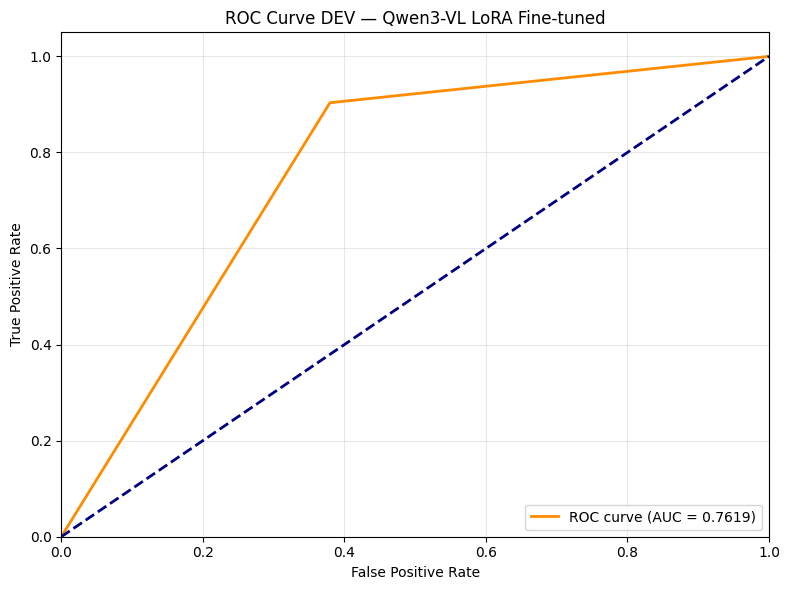

In [14]:
# Poner modelo en modo evaluación
model.eval()

val_results = process_dataset(val_df, DATA_BASE_DIR, model, processor, split_name="dev")

y_pred_labels = [label_map[r['classification']] for r in val_results]
y_true_labels = [label_map[r['true_label']] for r in val_results]
y_probs_dev   = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in val_results]

accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average='macro', zero_division=0
)

save_probs_json(val_df['id_EXIST'].values, y_probs_dev, 'dev', labels=val_df['label_int'].values)

print(f"\n{'='*50}")
print(f"  Métricas en DEV (Qwen3-VL LoRA Fine-tuned)")
print(f"{'='*50}")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

fpr, tpr, _ = roc_curve(y_true_labels, y_probs_dev)
roc_auc = auc(fpr, tpr)
print(f"\n  AUC (DEV): {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve DEV — Qwen3-VL LoRA Fine-tuned')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Evaluación en DEV con PyEvALL

In [15]:
from pyevall.evaluation import PyEvALLEvaluation
from pyevall.metrics.metricfactory import MetricFactory

# ─── Predicciones en formato PyEvALL ───
dev_preds_for_pyevall = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in val_results
]
dev_preds_df   = pd.DataFrame(dev_preds_for_pyevall)
dev_preds_path = os.path.join(PREDICTIONS_DIR, f'{GROUP_ID}_{MODEL_ID_TAG}_dev_predictions_temp.json')
with open(dev_preds_path, 'w', encoding='utf-8') as f:
    f.write(dev_preds_df.to_json(orient='records'))

# ─── Gold standard en formato PyEvALL ───
dev_gold = [
    {'test_case': 'EXIST2025', 'id': str(id_exist), 'value': label}
    for id_exist, label in zip(val_df['id_EXIST'].values, val_df[LABEL_COLUMN].values)
]
dev_gold_df   = pd.DataFrame(dev_gold)
dev_gold_path = os.path.join(PREDICTIONS_DIR, f'{GROUP_ID}_{MODEL_ID_TAG}_dev_gold_temp.json')
with open(dev_gold_path, 'w', encoding='utf-8') as f:
    f.write(dev_gold_df.to_json(orient='records'))

# ─── Evaluar con PyEvALL ───
test_eval = PyEvALLEvaluation()
metrics   = [MetricFactory.Accuracy.value, MetricFactory.FMeasure.value]
report    = test_eval.evaluate(dev_preds_path, dev_gold_path, metrics)
print("\n=== Evaluación en DEV con PyEvALL ===")
report.print_report()

2026-03-07 22:55:49,939 - pyevall.evaluation - INFO -             evaluate() - Evaluating the following metrics ['Accuracy', 'FMeasure']


2026-03-07 22:55:50,037 - pyevall.metrics.metrics - INFO -             evaluate() - Executing accuracy evaluation method


2026-03-07 22:55:50,279 - pyevall.metrics.metrics - INFO -             evaluate() - Executing fmeasure evaluation method



=== Evaluación en DEV con PyEvALL ===
{
  "metrics": {
    "Accuracy": {
      "name": "Accuracy",
      "acronym": "Acc",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "average": 0.7895716945996276
        }],
        "average_per_test_case": 0.7895716945996276
      }
    },
    "FMeasure": {
      "name": "F-Measure",
      "acronym": "F1",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "classes": {
            "YES": 0.8369408369408369,
            "NO": 0.7034120734908137
          },
          "average": 0.7701764552158252
        }],
        "average_per_test_case": 0.7701764552158252
      }
    }
  },
  "files": {
    "BeingChillingWeWillWin_qwen3vl8bFT_dev_predictions_temp.json": {
      "name": "BeingChillingWeWillWin_qwen3vl8bFT_dev_predictions_temp.json",
      "status": "OK",
   

## 13. Inferencia en TEST y generación de predicciones finales

In [16]:
test_results = process_dataset(test_df, DATA_BASE_DIR, model, processor, split_name="test")

y_probs_test = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in test_results]
test_preds   = [r['classification'] for r in test_results]

save_probs_json(test_df['id_EXIST'].values, y_probs_test, 'test')

print(f"\nPredicciones en TEST:")
print(f"  Total: {len(test_preds)}")
print(f"  YES  : {sum(1 for p in test_preds if p == 'YES')} ({100*sum(1 for p in test_preds if p == 'YES')/len(test_preds):.2f}%)")
print(f"  NO   : {sum(1 for p in test_preds if p == 'NO')} ({100*sum(1 for p in test_preds if p == 'NO')/len(test_preds):.2f}%)")

Inferencia test:   0%|          | 0/687 [00:00<?, ?it/s]

  Probabilidades guardadas en: ../predictions/BeingChillingWeWillWin_qwen3vl8bFT_probs_test.json

Predicciones en TEST:
  Total: 687
  YES  : 470 (68.41%)
  NO   : 217 (31.59%)


## 14. Guardar predicciones en formato PyEvALL para TEST

In [17]:
test_preds_for_submission = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in test_results
]
test_preds_df = pd.DataFrame(test_preds_for_submission)

output_filename = f"{GROUP_ID}_{MODEL_ID_TAG}.json"
output_path     = os.path.join(PREDICTIONS_DIR, output_filename)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(test_preds_df.to_json(orient='records'))

print(f"\n✓ Predicciones guardadas en: {output_path}")


✓ Predicciones guardadas en: ../predictions/BeingChillingWeWillWin_qwen3vl8bFT.json
